 Arabic Dialect Detection using Classical Machine Learning

## Task Overview
This notebook builds a **Classical Machine Learning pipeline** for detecting Arabic dialects from speech audio.

### Selected Dialects
We will classify between 4 Arabic dialects:

1. Egyptian (EGY)
2. Moroccan (MOR)
3. Iraq (IRA)
4. Lebnan (LEB)

### Dataset
Dataset used:

`ADI-17 Dataset`

Dataset structure example:

```text
adi17_organized/
    EGY/
    MOR/
    IRA/
    LEB/
```

---

In [1]:
from google.colab import files
files.upload()          # upload kaggle.json

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d basselabdelmonem/adi-17-dataset

import zipfile
with zipfile.ZipFile('adi-17-dataset.zip', 'r') as z:
    z.extractall('data')

import os
base_path = 'data/adi17_organized'
print('Folders found:', os.listdir(base_path))

mv: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/basselabdelmonem/adi-17-dataset
License(s): MIT
adi-17-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Folders found: ['ALG', 'QAT', 'SUD', 'JOR', 'PAL', 'MOR', 'LEB', 'KUW', 'IRA', 'SYR', 'OMA', 'YEM', 'LIB', 'KSA', 'MAU', 'EGY', 'UAE']


# 1. Install Required Libraries


In [2]:
!pip install librosa soundfile scikit-learn matplotlib seaborn pandas numpy joblib

# 2. Import Libraries


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

import joblib

# 3. Dataset Paths


In [4]:
DATASET_PATH = "data/adi17_organized"

DIALECTS = {
    "LEB": "Lebanese",
    "MOR": "Moroccan",
    "IRA": "Iraqi",
    "EGY": "Egyptian"
}

 4. Feature Extraction

We will use:

- MFCCs
- Chroma Features
- Spectral Contrast
- Zero Crossing Rate
- RMS Energy

These are classical audio-processing features widely used in speech and dialect classification.

---

## Why These Features?

### MFCCs
Capture pronunciation and vocal tract characteristics.

### Chroma
Capture tonal information.

### Spectral Contrast
Shows differences between peaks and valleys in speech frequencies.

### Zero Crossing Rate
Measures speech sharpness and speaking style.

### RMS Energy
Represents loudness and speaking dynamics.

---

# 5. Audio Feature Extraction Function


In [5]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050)

        # MFCC
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfccs_mean = np.mean(mfccs.T, axis=0)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)

        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)

        # RMS Energy
        rms = librosa.feature.rms(y=y)
        rms_mean = np.mean(rms)

        features = np.hstack([
            mfccs_mean,
            chroma_mean,
            contrast_mean,
            zcr_mean,
            rms_mean
        ])

        return features

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# 6. Load Dataset and Build Feature Matrix


In [6]:
X = []
y = []

for dialect_code, dialect_name in DIALECTS.items():

    dialect_folder = os.path.join(DATASET_PATH, dialect_code)

    for file in os.listdir(dialect_folder):

        if file.endswith('.wav'):

            file_path = os.path.join(dialect_folder, file)

            features = extract_features(file_path)

            if features is not None:
                X.append(features)
                y.append(dialect_name)

X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (800, 34)
Labels Shape: (800,)


# 7. Train-Test Split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8. Feature Scaling

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. Train Classical ML Model

## Support Vector Machine (SVM) — Fixed

**Problem:** The original model with `C=10` was too aggressive,
causing it to overfit to Iraqi patterns and predict Iraqi for
Lebanese and Sudanese samples.

**Fix:**
- `class_weight='balanced'` — forces the SVM to treat all 4 dialects equally
- `C=1` — reduced from 10 to prevent overfitting
- `kernel='rbf'` and `gamma='scale'` — kept the same

---

In [9]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

# Define your base estimator
base_model = SVC(
    kernel='rbf',
    C=5,
    gamma='scale',
    class_weight='balanced',
    probability=True
)

# Wrap it in One-vs-Rest
model = OneVsRestClassifier(base_model)

model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


# 10. Evaluate Model

In [10]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

    Egyptian       0.95      0.97      0.96        40
       Iraqi       1.00      1.00      1.00        40
    Lebanese       1.00      0.93      0.96        40
    Moroccan       0.95      1.00      0.98        40

    accuracy                           0.97       160
   macro avg       0.98      0.98      0.97       160
weighted avg       0.98      0.97      0.97       160



# 11. Confusion Matrix


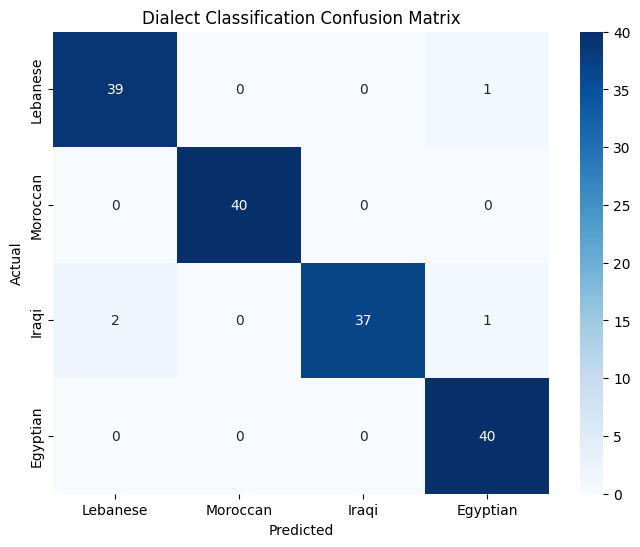

In [11]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=DIALECTS.values(),
    yticklabels=DIALECTS.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dialect Classification Confusion Matrix")

plt.show()

# 12. Spectrogram Visualization

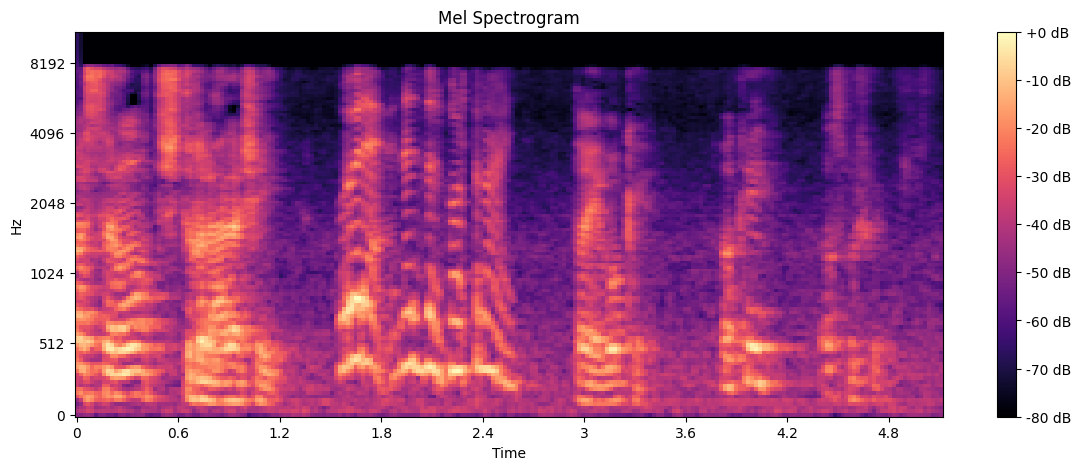

In [12]:
sample_file = "data/adi17_organized/KSA/KSA_3zis4y0fpMc_003243-003754.wav"

signal, sr = librosa.load(sample_file, sr=22050)

plt.figure(figsize=(14,5))

spectrogram = librosa.feature.melspectrogram(
    y=signal,
    sr=sr
)

spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')

plt.show()

 13. Visualizing Distinguishing Features

To show distinguishable differences between dialects, we visualize the MFCC distributions.

In [13]:
mfcc_data = []

for dialect_code, dialect_name in DIALECTS.items():

    dialect_folder = os.path.join(DATASET_PATH, dialect_code)

    for file in os.listdir(dialect_folder)[:20]:

        if file.endswith('.wav'):

            path = os.path.join(dialect_folder, file)

            signal, sr = librosa.load(path, sr=22050)

            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

            mfcc_mean = np.mean(mfcc, axis=1)

            mfcc_data.append([
                dialect_name,
                mfcc_mean[0],
                mfcc_mean[1]
            ])

mfcc_df = pd.DataFrame(
    mfcc_data,
    columns=['Dialect', 'MFCC1', 'MFCC2']
)

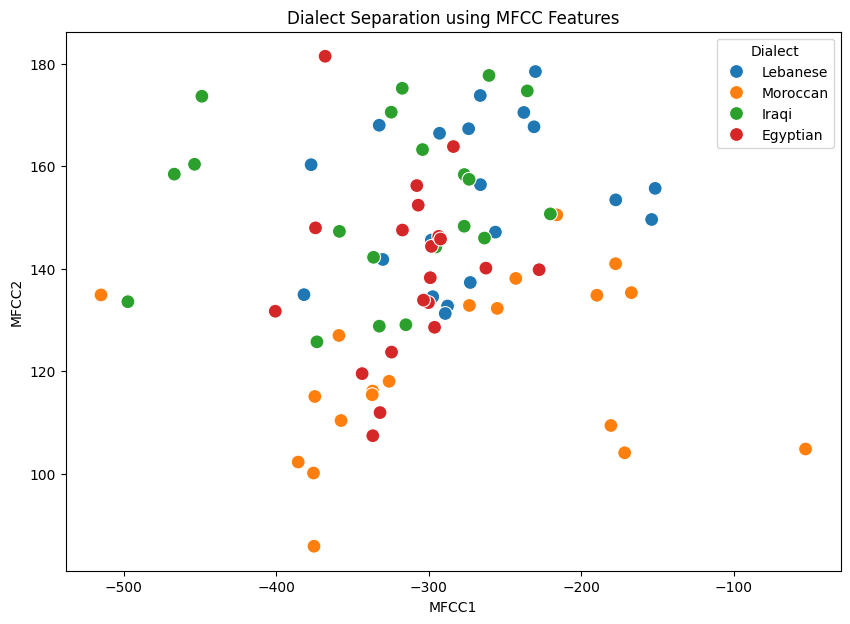

In [14]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=mfcc_df,
    x='MFCC1',
    y='MFCC2',
    hue='Dialect',
    s=100
)

plt.title('Dialect Separation using MFCC Features')

plt.show()

# 14. PCA Visualization

Reduce feature dimensions for visualization.

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Dialect': y
})

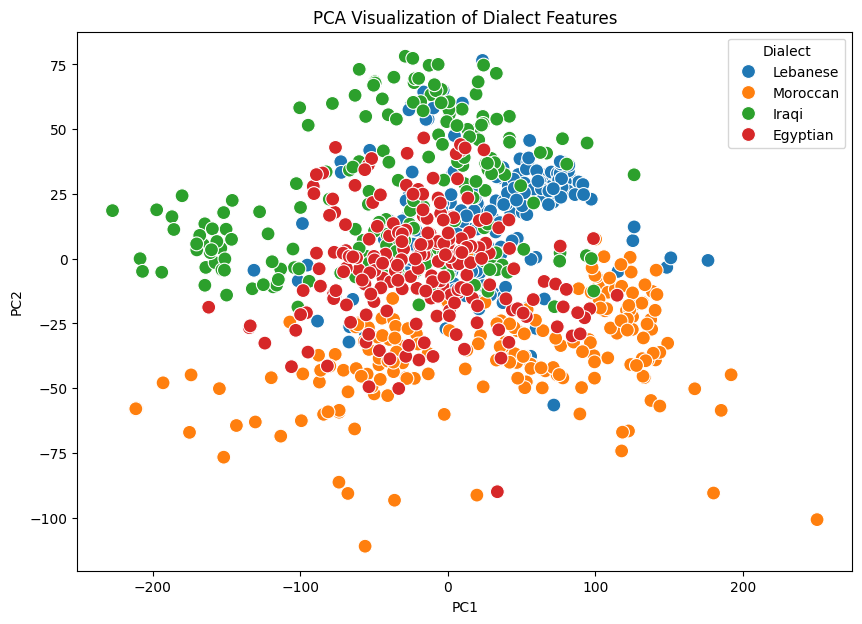

In [16]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Dialect',
    s=100
)

plt.title('PCA Visualization of Dialect Features')

plt.show()

# 15. Predict New Audio File

In [17]:
def predict_dialect(audio_path):
    features = extract_features(audio_path)
    if features is None:
        print('Feature extraction failed.')
        return

    features_scaled = scaler.transform([features])
    probabilities = model.predict_proba(features_scaled)[0]

    # Always pick the class with highest probability
    best_idx   = np.argmax(probabilities)
    prediction = model.classes_[best_idx]

    print(f'Predicted Dialect: {prediction}')
    print()
    for dialect, prob in sorted(zip(model.classes_, probabilities), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f'  {dialect:<12} {prob:.2f}  {bar}')


In [18]:
predict_dialect("/content/Iraq.m4a")

/tmp/ipykernel_6185/4114712929.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Predicted Dialect: Iraqi

  Iraqi        0.99  █████████████████████████████
  Moroccan     0.00  
  Egyptian     0.00  
  Lebanese     0.00  


# 16. Save Trained Model

In [19]:
joblib.dump(model, "dialect_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# 17. Load Model Later


In [20]:
model = joblib.load("dialect_model.pkl")
scaler = joblib.load("scaler.pkl")

# 18. Weighted Average Between Two Audio Files
This supports Task 5 requirement.

The user can combine two dialects with a weighting slider.

Example:

- 70% Egyptian
- 30% Moroccan

Then classify the mixed signal.

In [21]:
def mix_audio(file1, file2, weight=0.5):

    y1, sr1 = librosa.load(file1, sr=22050)
    y2, sr2 = librosa.load(file2, sr=22050)

    min_len = min(len(y1), len(y2))

    y1 = y1[:min_len]
    y2 = y2[:min_len]

    mixed = (weight * y1) + ((1 - weight) * y2)

    return mixed, sr1

In [22]:
mixed_signal, sr = mix_audio(
    "/content/data/adi17_organized/EGY/EGY_-DZMl0GUwtE_226439-227161.wav",
    "/content/data/adi17_organized/MOR/MOR_GD8SLIoqkj8_025688-026516.wav",
    weight=0.7
)


# 19. Feature Extraction from Signal


In [23]:
def extract_features_from_signal(y, sr):

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    contrast_mean = np.mean(contrast.T, axis=0)

    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)

    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)

    features = np.hstack([
        mfccs_mean,
        chroma_mean,
        contrast_mean,
        zcr_mean,
        rms_mean
    ])

    return features

# 20. Predict Mixed Audio


In [24]:
features = extract_features_from_signal(mixed_signal, sr)

features = scaler.transform([features])

prediction = model.predict(features)[0]

probabilities = model.predict_proba(features)[0]

print("Mixed Audio Prediction:", prediction)

for dialect, prob in zip(model.classes_, probabilities):
    print(f"{dialect}: {prob:.2f}")

Mixed Audio Prediction: Moroccan
Egyptian: 0.46
Iraqi: 0.00
Lebanese: 0.00
Moroccan: 0.54
